# Group D: Common VAE Experimental Baseline

**Course:** PhD CS — Image Processing  
**Assigned activity:** Variational Autoencoder (VAE) Image Generation  
**Dataset:** MNIST handwritten digits  
**Framework:** PyTorch

This notebook is the group's **shared minimum baseline**. It implements the common dataset, model, generation, interpolation, FFT, and evaluation pipeline. Each member should create a separate copy or Git branch and extend it according to the assigned research role.

| Member | Required role | Individual focus |
|---|---|---|
| **Manasan** | Model Development / Latent-Space Behavior | Changes in image structure during interpolation |
| **Almazan** | Frequency-Domain Analysis | FFT behavior, spectral smoothness, and frequency consistency |
| **Dampios** | Performance Evaluation / Quality Analysis | Reconstruction/generation quality, SSIM, PSNR, MSE, and spectral error |

> **Important:** The common code and checkpoint may be shared, but the individual analyses, visualizations, interpretations, reflections, and conclusions must be different.

## 1. Shared research scope

The baseline answers only the minimum common questions:

1. Can a simple VAE learn a usable latent representation of MNIST images?
2. Can the trained decoder reconstruct and generate images?
3. Does linear interpolation between two encoded images produce a gradual visual transition?
4. What do the spatial images and their FFT magnitude spectra look like?
5. Are consecutive interpolation samples reasonably smooth in both pixel and frequency space?
6. How similar are reconstructed images to their corresponding originals under basic quality metrics?

The baseline does **not** attempt to provide the members' final individual conclusions. The final reports should add deeper role-specific experiments.

## 2. Imports and project configuration

This cell imports the required libraries and defines all baseline settings in one place. Keeping the settings centralized makes the experiment easier to reproduce and modify.

The default configuration uses only a subset of MNIST and a small fully connected VAE so the notebook remains practical on a CPU. Set `TRAIN_LIMIT = None` and `TEST_LIMIT = None` to use the full dataset.

In [1]:
from pathlib import Path
import math
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from skimage.metrics import structural_similarity
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# -----------------------------
# Reproducibility and workload
# -----------------------------
SEED = 42
BATCH_SIZE = 128
EPOCHS = 5
LEARNING_RATE = 1e-3
TRAIN_LIMIT = None       # Use None for all 60,000 MNIST training images.
TEST_LIMIT = None         # Use None for all 10,000 MNIST test images.
NUM_WORKERS = 0            # Keep 0 for maximum Jupyter/Windows compatibility.
FORCE_RETRAIN = False      # Set True after changing the architecture or training settings.

# -----------------------------
# VAE configuration
# -----------------------------
IMAGE_HEIGHT = 28
IMAGE_WIDTH = 28
IMAGE_CHANNELS = 1
INPUT_DIM = IMAGE_HEIGHT * IMAGE_WIDTH
HIDDEN_DIM = 400
LATENT_DIM = 16
BETA = 1.0                 # Weight of the KL-divergence term.

# -----------------------------
# Shared baseline evaluations
# -----------------------------
NUM_DISPLAY_IMAGES = 10
NUM_GENERATED_IMAGES = 10
NUM_INTERPOLATION_STEPS = 9
INTERPOLATION_LABEL_A = 1
INTERPOLATION_LABEL_B = 7
MAX_METRIC_IMAGES = 200
SET_COMPARISON_IMAGES = 128

# Resolve paths whether Jupyter starts in the repository root or notebooks/.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
EXPORT_DIR = PROJECT_ROOT / "exports"

for directory in (DATA_DIR, MODEL_DIR, OUTPUT_DIR, EXPORT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = MODEL_DIR / f"common_vae_mnist_z{LATENT_DIM}_h{HIDDEN_DIM}.pt"
HISTORY_PATH = OUTPUT_DIR / f"common_training_history_z{LATENT_DIM}.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Checkpoint:   {CHECKPOINT_PATH}")

Project root: Y:\PHDCS\PHDCS103\group_d_vae_common_baseline\group_d_vae_common_baseline
Checkpoint:   Y:\PHDCS\PHDCS103\group_d_vae_common_baseline\group_d_vae_common_baseline\models\common_vae_mnist_z16_h400.pt


## 3. Reproducibility and compute device

Random seeds are fixed so that dataset subsets, parameter initialization, random generations, and interpolation selections are repeatable. The notebook uses a CUDA-compatible GPU when one is available and otherwise runs on the CPU.

In [2]:
def set_reproducible_seed(seed: int) -> None:
    """Set Python, NumPy, and PyTorch seeds for repeatable experiments."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # These options improve repeatability on CUDA devices.
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_reproducible_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.13.0+cpu


## 4. Dataset description and preparation

**MNIST** contains grayscale images of handwritten digits from 0 to 9. Each image has a spatial resolution of **28 × 28 pixels** and one channel. The standard split contains 60,000 training images and 10,000 test images.

The only required preprocessing is conversion to a PyTorch tensor. `ToTensor()` scales each pixel to the range `[0, 1]`, which matches the decoder's sigmoid output and the binary cross-entropy reconstruction loss used below.

The deterministic subset is only a runtime convenience. All three members should use the same subset settings unless a member is explicitly studying dataset size as an individual experiment.

In [3]:
transform = transforms.ToTensor()

full_train_dataset = datasets.MNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform,
)
full_test_dataset = datasets.MNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=transform,
)


def make_deterministic_subset(dataset, limit: int | None, seed: int):
    """Return the full dataset or a repeatable random subset."""
    if limit is None or limit >= len(dataset):
        return dataset

    generator = torch.Generator().manual_seed(seed)
    indices = torch.randperm(len(dataset), generator=generator)[:limit].tolist()
    return Subset(dataset, indices)


train_dataset = make_deterministic_subset(full_train_dataset, TRAIN_LIMIT, SEED)
test_dataset = make_deterministic_subset(full_test_dataset, TEST_LIMIT, SEED + 1)

loader_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    generator=loader_generator,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

print(f"Full training set: {len(full_train_dataset):,}")
print(f"Used training set: {len(train_dataset):,}")
print(f"Full test set:     {len(full_test_dataset):,}")
print(f"Used test set:     {len(test_dataset):,}")
print(f"Image tensor shape: {train_dataset[0][0].shape}")
print(f"Pixel range: [{train_dataset[0][0].min().item():.1f}, {train_dataset[0][0].max().item():.1f}]")

100.0%
100.0%
100.0%
100.0%

Full training set: 60,000
Used training set: 60,000
Full test set:     10,000
Used test set:     10,000
Image tensor shape: torch.Size([1, 28, 28])
Pixel range: [0.0, 1.0]


## 5. Initial inspection of real images

Before training, inspect several real samples to verify the labels, image dimensions, grayscale format, and general variability of the dataset. This is also a basic data-quality check.

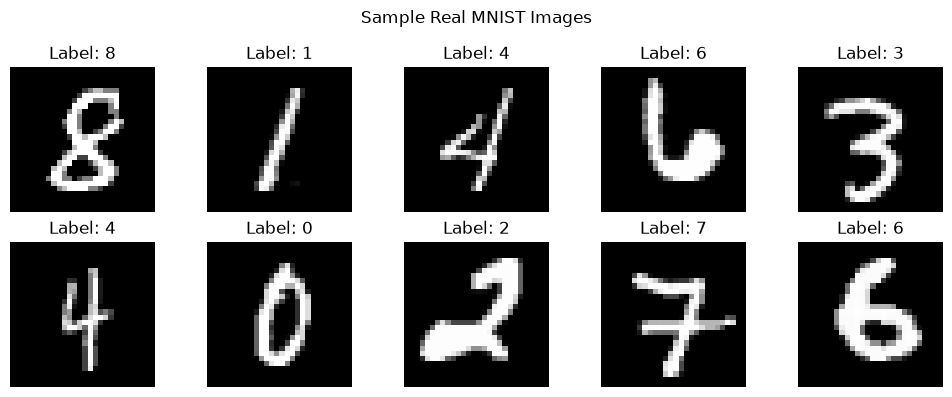

In [4]:
sample_images, sample_labels = next(iter(train_loader))

figure, axes = plt.subplots(2, 5, figsize=(10, 4))
for axis, image, label in zip(axes.ravel(), sample_images[:10], sample_labels[:10]):
    axis.imshow(image.squeeze(0), cmap="gray")
    axis.set_title(f"Label: {int(label)}")
    axis.axis("off")

figure.suptitle("Sample Real MNIST Images")
figure.tight_layout()
plt.show()

## 6. Baseline VAE architecture

The model is intentionally simple:

- The **encoder** flattens each 28 × 28 image and maps it to a hidden representation.
- Two encoder heads estimate the latent mean `μ` and log-variance `log(σ²)`.
- The **reparameterization trick** samples `z = μ + σ × ε`, where `ε` is standard Gaussian noise.
- The **decoder** maps `z` back to a 28 × 28 image using a sigmoid output.

A latent dimension of 16 is a practical baseline. Members may change it only in their individual experiments, because changing it requires retraining the model.

In [5]:
class VariationalAutoencoder(nn.Module):
    """A compact fully connected VAE for 28 × 28 grayscale images."""

    def __init__(self, input_dim: int, hidden_dim: int, latent_dim: int):
        super().__init__()

        self.encoder_backbone = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
        )
        self.encoder_mu = nn.Linear(hidden_dim, latent_dim)
        self.encoder_logvar = nn.Linear(hidden_dim, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid(),
        )

    def encode(self, images: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        hidden = self.encoder_backbone(images)
        return self.encoder_mu(hidden), self.encoder_logvar(hidden)

    @staticmethod
    def reparameterize(mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        standard_deviation = torch.exp(0.5 * logvar)
        noise = torch.randn_like(standard_deviation)
        return mu + standard_deviation * noise

    def decode(self, latent_vectors: torch.Tensor) -> torch.Tensor:
        reconstructed = self.decoder(latent_vectors)
        return reconstructed.view(-1, IMAGE_CHANNELS, IMAGE_HEIGHT, IMAGE_WIDTH)

    def forward(
        self, images: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        mu, logvar = self.encode(images)
        latent_vectors = self.reparameterize(mu, logvar)
        reconstructed = self.decode(latent_vectors)
        return reconstructed, mu, logvar


model = VariationalAutoencoder(INPUT_DIM, HIDDEN_DIM, LATENT_DIM).to(DEVICE)
print(model)
print(f"Trainable parameters: {sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad):,}")

VariationalAutoencoder(
  (encoder_backbone): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=400, bias=True)
    (2): ReLU()
  )
  (encoder_mu): Linear(in_features=400, out_features=16, bias=True)
  (encoder_logvar): Linear(in_features=400, out_features=16, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=400, bias=True)
    (1): ReLU()
    (2): Linear(in_features=400, out_features=784, bias=True)
    (3): Sigmoid()
  )
)
Trainable parameters: 648,016


## 7. VAE objective and training functions

The total VAE loss contains two terms:

1. **Reconstruction loss:** binary cross-entropy between the input and reconstructed image.
2. **KL-divergence loss:** regularizes the latent distribution toward a standard normal distribution.

The baseline uses `β = 1`. The loss values reported per epoch are divided by the number of images, making runs with different subset sizes easier to compare.

In [6]:
def compute_vae_loss(
    reconstructed: torch.Tensor,
    original: torch.Tensor,
    mu: torch.Tensor,
    logvar: torch.Tensor,
    beta: float = BETA,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Return total, reconstruction, and KL-divergence losses."""
    reconstruction_loss = F.binary_cross_entropy(
        reconstructed,
        original,
        reduction="sum",
    )
    kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    total_loss = reconstruction_loss + beta * kl_divergence
    return total_loss, reconstruction_loss, kl_divergence


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer | None = None,
) -> dict[str, float]:
    """Train for one epoch when optimizer is supplied; otherwise evaluate."""
    is_training = optimizer is not None
    model.train(mode=is_training)

    totals = {"total": 0.0, "reconstruction": 0.0, "kl": 0.0}
    image_count = 0

    for images, _ in loader:
        images = images.to(DEVICE)
        batch_size = images.size(0)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            reconstructed, mu, logvar = model(images)
            total_loss, reconstruction_loss, kl_divergence = compute_vae_loss(
                reconstructed,
                images,
                mu,
                logvar,
            )

            if is_training:
                total_loss.backward()
                optimizer.step()

        totals["total"] += total_loss.item()
        totals["reconstruction"] += reconstruction_loss.item()
        totals["kl"] += kl_divergence.item()
        image_count += batch_size

    return {name: value / image_count for name, value in totals.items()}

## 8. Train the common model or reload its checkpoint

On the first run, this cell trains the VAE and saves the weights in `models/`. On later runs, it reloads the checkpoint to keep the common baseline stable.

Set `FORCE_RETRAIN = True` when the architecture, latent dimension, or major preprocessing settings have changed. All group members should use the same common checkpoint before beginning individual experiments.

In [7]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
history_records: list[dict[str, float]] = []
loaded_checkpoint = False

if CHECKPOINT_PATH.exists() and not FORCE_RETRAIN:
    try:
        state_dict = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
        model.load_state_dict(state_dict)
        loaded_checkpoint = True
        print(f"Loaded existing checkpoint: {CHECKPOINT_PATH}")
    except RuntimeError as error:
        print("The existing checkpoint is incompatible with the current model.")
        print(f"Reason: {error}")
        print("A new model will be trained and the checkpoint will be replaced.")

if not loaded_checkpoint:
    training_start = time.perf_counter()

    for epoch in range(1, EPOCHS + 1):
        train_metrics = run_epoch(model, train_loader, optimizer)
        test_metrics = run_epoch(model, test_loader)

        record = {
            "epoch": epoch,
            "train_total": train_metrics["total"],
            "train_reconstruction": train_metrics["reconstruction"],
            "train_kl": train_metrics["kl"],
            "test_total": test_metrics["total"],
            "test_reconstruction": test_metrics["reconstruction"],
            "test_kl": test_metrics["kl"],
        }
        history_records.append(record)

        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"train loss/image={train_metrics['total']:.3f} | "
            f"test loss/image={test_metrics['total']:.3f}"
        )

    torch.save(model.state_dict(), CHECKPOINT_PATH)
    pd.DataFrame(history_records).to_csv(HISTORY_PATH, index=False)
    elapsed = time.perf_counter() - training_start
    print(f"Training finished in {elapsed:.1f} seconds.")
    print(f"Saved checkpoint: {CHECKPOINT_PATH}")
else:
    if HISTORY_PATH.exists():
        history_records = pd.read_csv(HISTORY_PATH).to_dict("records")

model.eval()

Epoch 01/5 | train loss/image=163.473 | test loss/image=125.217
Epoch 02/5 | train loss/image=120.293 | test loss/image=115.543
Epoch 03/5 | train loss/image=114.472 | test loss/image=111.927
Epoch 04/5 | train loss/image=111.795 | test loss/image=110.042
Epoch 05/5 | train loss/image=110.219 | test loss/image=108.728
Training finished in 101.7 seconds.
Saved checkpoint: Y:\PHDCS\PHDCS103\group_d_vae_common_baseline\group_d_vae_common_baseline\models\common_vae_mnist_z16_h400.pt


VariationalAutoencoder(
  (encoder_backbone): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=400, bias=True)
    (2): ReLU()
  )
  (encoder_mu): Linear(in_features=400, out_features=16, bias=True)
  (encoder_logvar): Linear(in_features=400, out_features=16, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=400, bias=True)
    (1): ReLU()
    (2): Linear(in_features=400, out_features=784, bias=True)
    (3): Sigmoid()
  )
)

## 9. Training history

The curves below are a basic sanity check. A generally decreasing reconstruction and total loss indicates that the model is learning. These curves alone do not establish generated-image quality; they should be interpreted together with reconstructions, generated samples, interpolation behavior, FFT results, and quantitative metrics.

,epoch,train_total,train_reconstruction,train_kl,test_total,test_reconstruction,test_kl
0,1,163.4729,148.5923,14.8806,125.2167,104.8762,20.3406
1,2,120.2933,99.1774,21.1159,115.5433,93.8286,21.7147
2,3,114.4717,92.4511,22.0206,111.9271,90.0796,21.8474
3,4,111.7953,89.3617,22.4337,110.0417,86.7980,23.2437
4,5,110.2188,87.5420,22.6768,108.7283,85.4115,23.3169


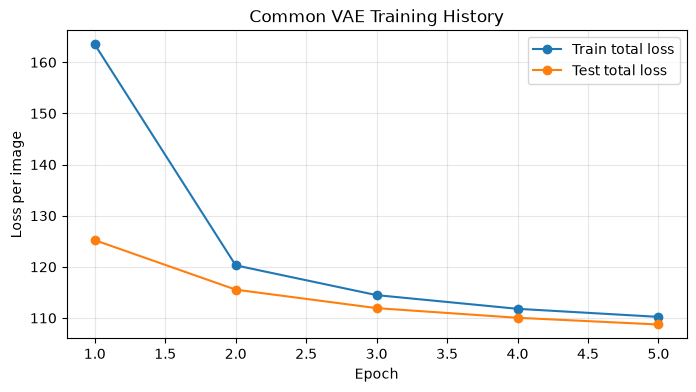

In [8]:
if history_records:
    history = pd.DataFrame(history_records)
    display(history.round(4))

    plt.figure(figsize=(8, 4))
    plt.plot(history["epoch"], history["train_total"], marker="o", label="Train total loss")
    plt.plot(history["epoch"], history["test_total"], marker="o", label="Test total loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss per image")
    plt.title("Common VAE Training History")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("No stored history was found. The checkpoint can still be evaluated below.")

## 10. Original-versus-reconstructed images

A reconstruction is produced by encoding a real test image and decoding its latent representation. This creates a meaningful one-to-one pair, so paired metrics such as MSE, PSNR, and SSIM can be applied later.

The baseline uses the encoder mean `μ` during evaluation instead of a random sample. This removes sampling noise and makes repeated reconstruction measurements more stable.

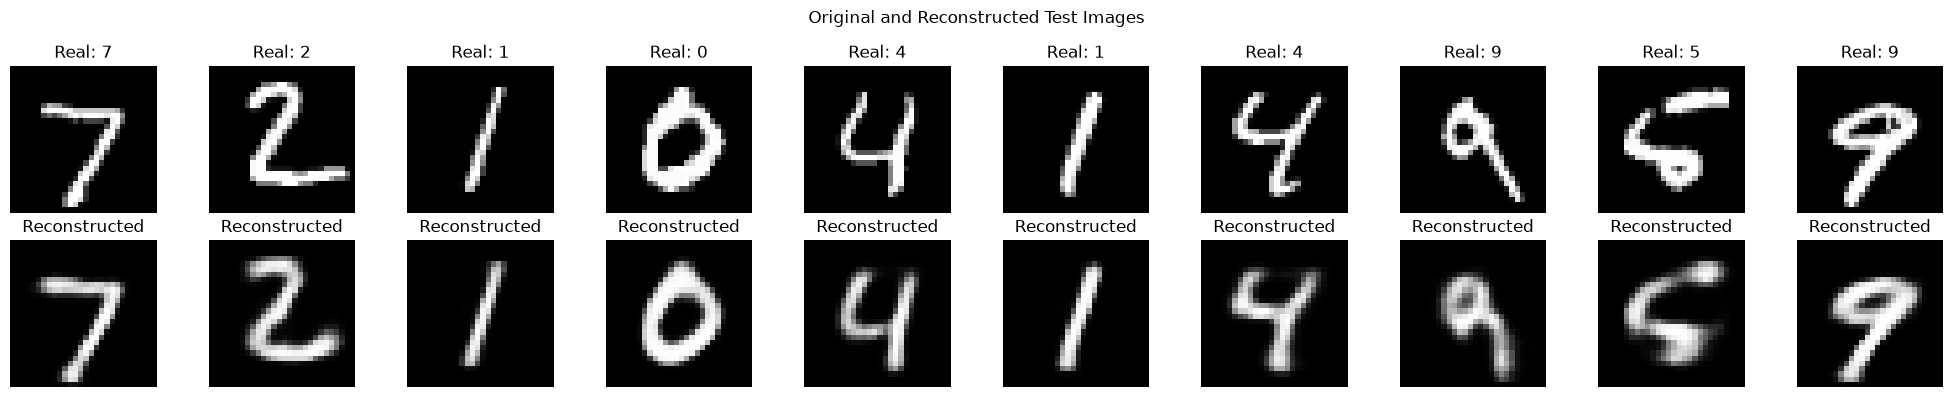

In [9]:
@torch.no_grad()
def reconstruct_images(
    model: VariationalAutoencoder,
    images: torch.Tensor,
) -> torch.Tensor:
    images = images.to(DEVICE)
    mu, _ = model.encode(images)
    return model.decode(mu).cpu()


test_images_batch, test_labels_batch = next(iter(test_loader))
original_examples = test_images_batch[:NUM_DISPLAY_IMAGES]
original_labels = test_labels_batch[:NUM_DISPLAY_IMAGES]
reconstructed_examples = reconstruct_images(model, original_examples)

figure, axes = plt.subplots(2, NUM_DISPLAY_IMAGES, figsize=(2 * NUM_DISPLAY_IMAGES, 4))
for index in range(NUM_DISPLAY_IMAGES):
    axes[0, index].imshow(original_examples[index].squeeze(0), cmap="gray")
    axes[0, index].set_title(f"Real: {int(original_labels[index])}")
    axes[0, index].axis("off")

    axes[1, index].imshow(reconstructed_examples[index].squeeze(0), cmap="gray")
    axes[1, index].set_title("Reconstructed")
    axes[1, index].axis("off")

axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("VAE output")
figure.suptitle("Original and Reconstructed Test Images")
figure.tight_layout()
plt.show()

## 11. Random image generation from the latent space

To generate new images, latent vectors are sampled from a standard normal distribution and passed directly to the decoder. These synthetic images have no exact paired ground truth, so PSNR and SSIM should **not** be calculated against arbitrary unrelated real images.

Set-level distributions, spectral summaries, or suitable generative-model metrics are more defensible for comparing random generations with a real dataset.

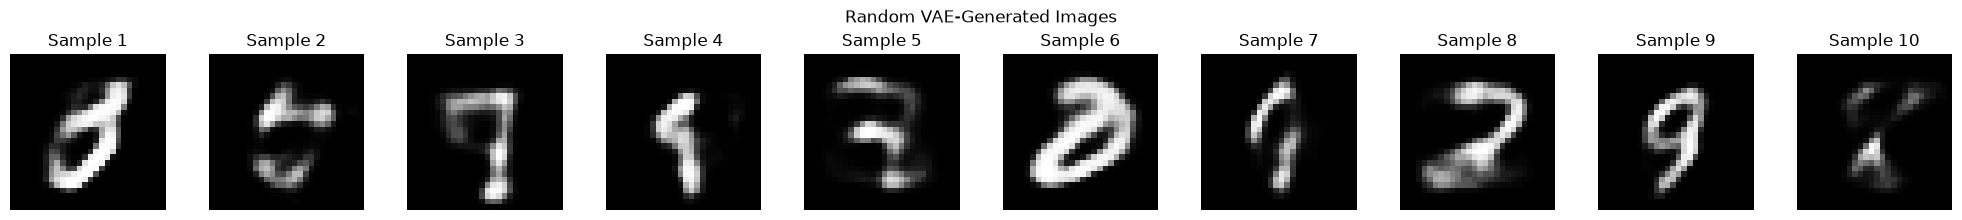

In [10]:
@torch.no_grad()
def generate_random_images(
    model: VariationalAutoencoder,
    number_of_images: int,
    seed: int = SEED + 100,
) -> torch.Tensor:
    generator = torch.Generator(device="cpu").manual_seed(seed)
    latent_vectors = torch.randn(number_of_images, LATENT_DIM, generator=generator).to(DEVICE)
    return model.decode(latent_vectors).cpu()


generated_examples = generate_random_images(model, NUM_GENERATED_IMAGES)

figure, axes = plt.subplots(1, NUM_GENERATED_IMAGES, figsize=(2 * NUM_GENERATED_IMAGES, 2.2))
for index, image in enumerate(generated_examples):
    axes[index].imshow(image.squeeze(0), cmap="gray")
    axes[index].set_title(f"Sample {index + 1}")
    axes[index].axis("off")

figure.suptitle("Random VAE-Generated Images")
figure.tight_layout()
plt.show()

## 12. Latent-space interpolation

Two real images with different labels are encoded into latent means. The notebook then performs linear interpolation:

\[
z(\alpha) = (1-\alpha)z_A + \alpha z_B, \qquad 0 \leq \alpha \leq 1
\]

Every intermediate latent vector is decoded into an image. This creates a controlled path for studying structural changes, spectral smoothness, frequency consistency, and quality behavior.

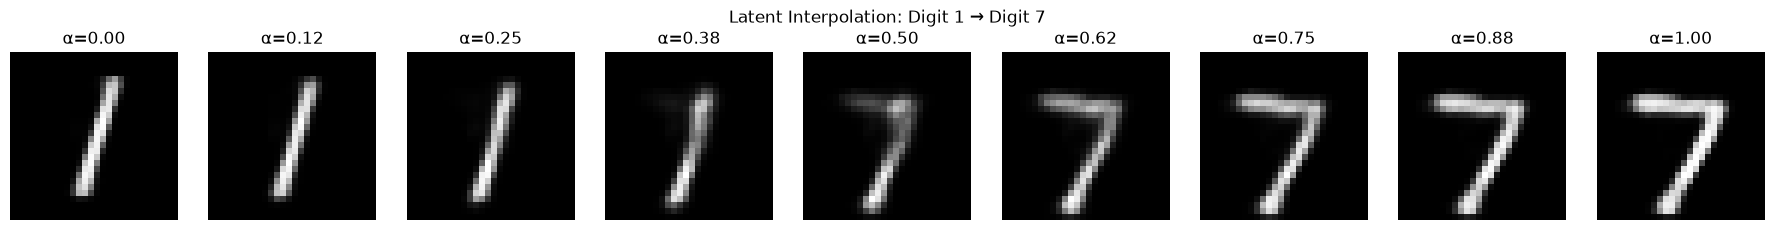

In [11]:
def find_first_image_with_label(dataset, requested_label: int) -> tuple[torch.Tensor, int]:
    """Return the first image in the selected dataset with the requested label."""
    for index in range(len(dataset)):
        image, label = dataset[index]
        if int(label) == requested_label:
            return image, int(label)
    raise ValueError(f"Label {requested_label} was not found in the selected test subset.")


@torch.no_grad()
def interpolate_between_images(
    model: VariationalAutoencoder,
    image_a: torch.Tensor,
    image_b: torch.Tensor,
    number_of_steps: int,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Encode two images, linearly interpolate their means, and decode the path."""
    image_a = image_a.unsqueeze(0).to(DEVICE)
    image_b = image_b.unsqueeze(0).to(DEVICE)

    mu_a, _ = model.encode(image_a)
    mu_b, _ = model.encode(image_b)

    alphas = torch.linspace(0.0, 1.0, number_of_steps, device=DEVICE).unsqueeze(1)
    latent_path = (1.0 - alphas) * mu_a + alphas * mu_b
    decoded_path = model.decode(latent_path).cpu()

    return decoded_path, alphas.squeeze(1).cpu()


source_image_a, source_label_a = find_first_image_with_label(
    test_dataset, INTERPOLATION_LABEL_A
)
source_image_b, source_label_b = find_first_image_with_label(
    test_dataset, INTERPOLATION_LABEL_B
)

interpolation_images, interpolation_alphas = interpolate_between_images(
    model,
    source_image_a,
    source_image_b,
    NUM_INTERPOLATION_STEPS,
)

figure, axes = plt.subplots(1, NUM_INTERPOLATION_STEPS, figsize=(2 * NUM_INTERPOLATION_STEPS, 2.3))
for index, (image, alpha) in enumerate(zip(interpolation_images, interpolation_alphas)):
    axes[index].imshow(image.squeeze(0), cmap="gray")
    axes[index].set_title(f"α={alpha.item():.2f}")
    axes[index].axis("off")

figure.suptitle(f"Latent Interpolation: Digit {source_label_a} → Digit {source_label_b}")
figure.tight_layout()
plt.show()

## 13. Two-dimensional FFT utilities

The 2D Fast Fourier Transform converts a grayscale image from the spatial domain to the frequency domain. `fftshift` moves the zero-frequency component to the center of the spectrum.

This notebook keeps two representations:

- **Magnitude spectrum:** `|F(u,v)|`
- **Log-magnitude spectrum:** `log(1 + |F(u,v)|)`

The logarithm compresses the large dynamic range and makes weaker frequency components easier to visualize.

In [12]:
def to_numpy_image(image: torch.Tensor | np.ndarray) -> np.ndarray:
    """Convert a tensor or array into a 2D floating-point grayscale image."""
    if isinstance(image, torch.Tensor):
        image = image.detach().cpu().numpy()
    image = np.asarray(image, dtype=np.float64).squeeze()
    if image.ndim != 2:
        raise ValueError(f"Expected a 2D grayscale image after squeezing, received {image.shape}.")
    return image


def fft_magnitude_maps(image: torch.Tensor | np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Return centered magnitude and log-magnitude spectra."""
    image_2d = to_numpy_image(image)
    frequency = np.fft.fftshift(np.fft.fft2(image_2d))
    magnitude = np.abs(frequency)
    log_magnitude = np.log1p(magnitude)
    return magnitude, log_magnitude

## 14. Baseline spatial-versus-frequency comparison

The next visualization compares one real image, its reconstruction, and one random generation. It is only a descriptive starting point. Each member should select and justify additional samples according to the individual role.

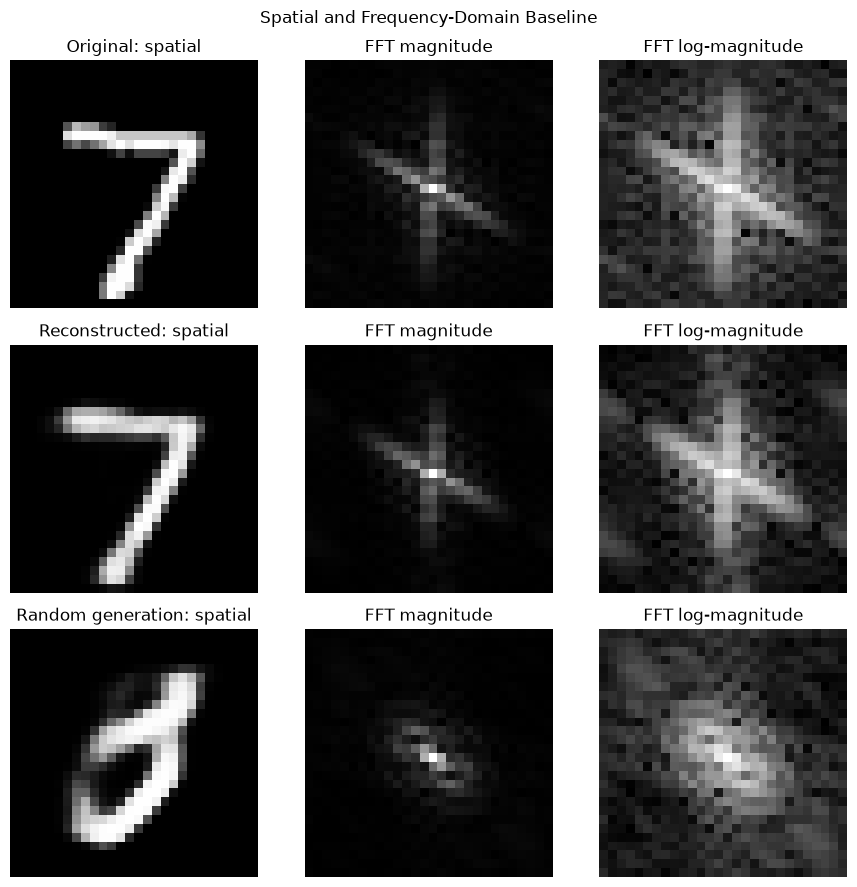

In [13]:
comparison_items = [
    ("Original", original_examples[0]),
    ("Reconstructed", reconstructed_examples[0]),
    ("Random generation", generated_examples[0]),
]

figure, axes = plt.subplots(len(comparison_items), 3, figsize=(9, 9))

for row, (name, image) in enumerate(comparison_items):
    magnitude, log_magnitude = fft_magnitude_maps(image)

    axes[row, 0].imshow(to_numpy_image(image), cmap="gray")
    axes[row, 0].set_title(f"{name}: spatial")

    axes[row, 1].imshow(magnitude, cmap="gray")
    axes[row, 1].set_title("FFT magnitude")

    axes[row, 2].imshow(log_magnitude, cmap="gray")
    axes[row, 2].set_title("FFT log-magnitude")

    for column in range(3):
        axes[row, column].axis("off")

figure.suptitle("Spatial and Frequency-Domain Baseline")
figure.tight_layout()
plt.show()

## 15. Frequency-domain view of the interpolation path

Each interpolation output is shown directly above its log-magnitude spectrum. The aligned layout makes it easier to inspect whether gradual spatial changes are accompanied by gradual spectral changes.

This is the common visualization only. Almazan's individual frequency-analysis notebook should add deeper measurements, more paths, and independent conclusions.

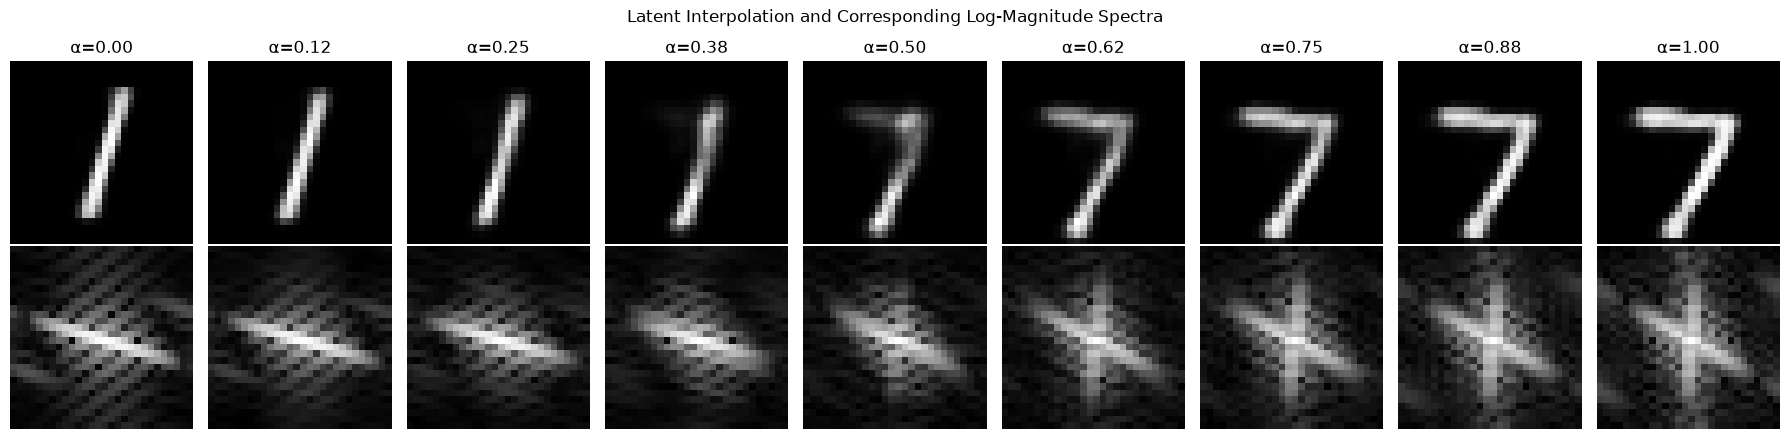

In [14]:
figure, axes = plt.subplots(
    2,
    NUM_INTERPOLATION_STEPS,
    figsize=(2 * NUM_INTERPOLATION_STEPS, 4.5),
)

for index, (image, alpha) in enumerate(zip(interpolation_images, interpolation_alphas)):
    _, log_magnitude = fft_magnitude_maps(image)

    axes[0, index].imshow(to_numpy_image(image), cmap="gray")
    axes[0, index].set_title(f"α={alpha.item():.2f}")
    axes[0, index].axis("off")

    axes[1, index].imshow(log_magnitude, cmap="gray")
    axes[1, index].axis("off")

axes[0, 0].set_ylabel("Spatial")
axes[1, 0].set_ylabel("Log FFT")
figure.suptitle("Latent Interpolation and Corresponding Log-Magnitude Spectra")
figure.tight_layout()
plt.show()

## 16. Minimal paired reconstruction metrics

These metrics are calculated only for **original–reconstructed pairs**, where every reconstructed image corresponds to a known original image.

- **MSE:** average squared pixel error; lower is better.
- **PSNR:** logarithmic reconstruction fidelity derived from MSE; higher is better.
- **SSIM:** structural similarity; values closer to 1 indicate greater structural agreement.
- **Spectral cosine similarity:** similarity between flattened log-magnitude FFT representations; values closer to 1 indicate more similar spectral patterns.

This is a shared sanity check, not Dampios's complete performance-evaluation analysis.

In [15]:
def mean_squared_error(reference: np.ndarray, estimate: np.ndarray) -> float:
    return float(np.mean((reference - estimate) ** 2))


def peak_signal_to_noise_ratio(reference: np.ndarray, estimate: np.ndarray) -> float:
    mse = mean_squared_error(reference, estimate)
    if mse == 0.0:
        return math.inf
    return float(10.0 * np.log10(1.0 / mse))


def spectral_cosine_similarity(reference: np.ndarray, estimate: np.ndarray) -> float:
    _, reference_spectrum = fft_magnitude_maps(reference)
    _, estimate_spectrum = fft_magnitude_maps(estimate)

    reference_vector = reference_spectrum.ravel()
    estimate_vector = estimate_spectrum.ravel()
    denominator = np.linalg.norm(reference_vector) * np.linalg.norm(estimate_vector)

    if denominator == 0.0:
        return 0.0
    return float(np.dot(reference_vector, estimate_vector) / denominator)


@torch.no_grad()
def evaluate_reconstruction_quality(
    model: VariationalAutoencoder,
    loader: DataLoader,
    maximum_images: int,
) -> pd.DataFrame:
    records: list[dict[str, float | int]] = []

    for images, labels in loader:
        reconstructions = reconstruct_images(model, images)

        for original, reconstructed, label in zip(images, reconstructions, labels):
            original_array = to_numpy_image(original)
            reconstructed_array = to_numpy_image(reconstructed)

            records.append(
                {
                    "label": int(label),
                    "mse": mean_squared_error(original_array, reconstructed_array),
                    "psnr_db": peak_signal_to_noise_ratio(original_array, reconstructed_array),
                    "ssim": float(
                        structural_similarity(
                            original_array,
                            reconstructed_array,
                            data_range=1.0,
                        )
                    ),
                    "spectral_cosine_similarity": spectral_cosine_similarity(
                        original_array,
                        reconstructed_array,
                    ),
                }
            )

            if len(records) >= maximum_images:
                return pd.DataFrame(records)

    return pd.DataFrame(records)


reconstruction_metrics = evaluate_reconstruction_quality(
    model,
    test_loader,
    MAX_METRIC_IMAGES,
)
reconstruction_metrics_path = OUTPUT_DIR / "common_reconstruction_metrics.csv"
reconstruction_metrics.to_csv(reconstruction_metrics_path, index=False)

metric_columns = ["mse", "psnr_db", "ssim", "spectral_cosine_similarity"]
reconstruction_summary = (
    reconstruction_metrics[metric_columns]
    .agg(["mean", "std", "min", "max"])
    .transpose()
)

display(reconstruction_summary.round(4))
print(f"Saved per-image metrics: {reconstruction_metrics_path}")

,mean,std,min,max
mse,0.0120,0.0070,0.0011,0.0364
psnr_db,20.0497,2.9056,14.3929,29.6724
ssim,0.8435,0.0858,0.3970,0.9686
spectral_cosine_similarity,0.9378,0.0238,0.8190,0.9741


Saved per-image metrics: Y:\PHDCS\PHDCS103\group_d_vae_common_baseline\group_d_vae_common_baseline\outputs\common_reconstruction_metrics.csv


## 17. Minimal interpolation smoothness measurements

For each pair of consecutive interpolation samples, the notebook calculates:

- **Spatial step MSE:** the average pixel change from one step to the next.
- **Spectral cosine similarity:** the similarity of consecutive log-magnitude FFT spectra.

These values provide a small numerical baseline for discussing smoothness and consistency. They should not be treated as the complete structural or frequency analysis.

In [16]:
interpolation_records: list[dict[str, float | int]] = []

for index in range(len(interpolation_images) - 1):
    current_image = to_numpy_image(interpolation_images[index])
    next_image = to_numpy_image(interpolation_images[index + 1])

    interpolation_records.append(
        {
            "from_step": index,
            "to_step": index + 1,
            "alpha_from": float(interpolation_alphas[index]),
            "alpha_to": float(interpolation_alphas[index + 1]),
            "spatial_step_mse": mean_squared_error(current_image, next_image),
            "spectral_cosine_similarity": spectral_cosine_similarity(
                current_image,
                next_image,
            ),
        }
    )

interpolation_metrics = pd.DataFrame(interpolation_records)
interpolation_metrics_path = OUTPUT_DIR / "common_interpolation_path_metrics.csv"
interpolation_metrics.to_csv(interpolation_metrics_path, index=False)

display(interpolation_metrics.round(5))
print(f"Saved interpolation metrics: {interpolation_metrics_path}")

,from_step,to_step,alpha_from,alpha_to,spatial_step_mse,spectral_cosine_similarity
0,0,1,0.000,0.125,0.00095,0.98571
1,1,2,0.125,0.250,0.00160,0.98831
2,2,3,0.250,0.375,0.00240,0.98284
3,3,4,0.375,0.500,0.00283,0.96608
4,4,5,0.500,0.625,0.00408,0.97042
5,5,6,0.625,0.750,0.00408,0.98901
6,6,7,0.750,0.875,0.00317,0.98947
7,7,8,0.875,1.000,0.00217,0.99037


Saved interpolation metrics: Y:\PHDCS\PHDCS103\group_d_vae_common_baseline\group_d_vae_common_baseline\outputs\common_interpolation_path_metrics.csv


## 18. Minimal real-versus-generated set comparison

A random generated image does not have a directly corresponding real image. Therefore, this baseline compares small **sets** rather than forcing arbitrary image pairs.

The visualization shows:

- the mean real image;
- the mean generated image;
- the mean real log-magnitude spectrum; and
- the mean generated log-magnitude spectrum.

The table also reports the fraction of FFT power found in low-, middle-, and high-frequency radial bands. These cutoffs are simple baseline choices and may be changed or justified more rigorously in the individual frequency analysis.

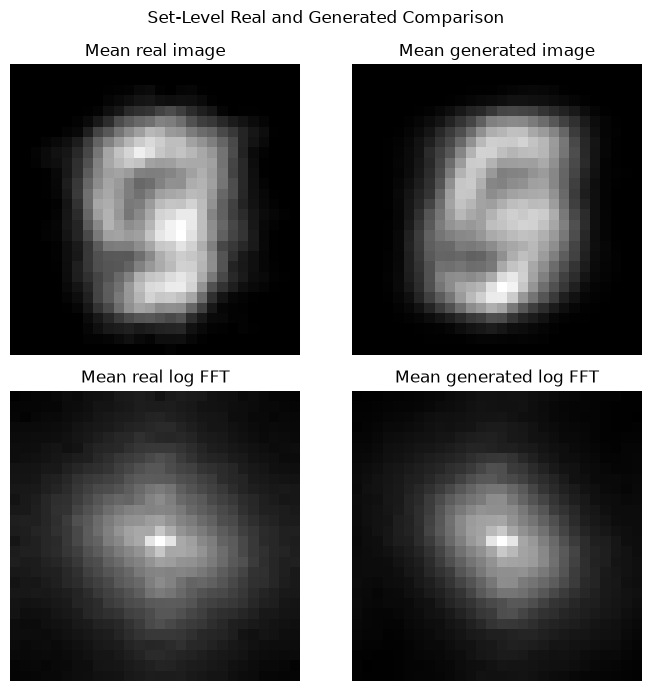

low            middle              high         
              mean      std     mean      std     mean      std
group                                                          
Generated  0.82183  0.05276  0.16836  0.04973  0.00981  0.00469
Real       0.68969  0.09245  0.26914  0.07570  0.04117  0.02284

Saved frequency-band measurements: Y:\PHDCS\PHDCS103\group_d_vae_common_baseline\group_d_vae_common_baseline\outputs\common_real_generated_frequency_bands.csv


In [17]:
def collect_images(loader: DataLoader, number_of_images: int) -> torch.Tensor:
    collected: list[torch.Tensor] = []
    current_count = 0

    for images, _ in loader:
        needed = number_of_images - current_count
        selected = images[:needed]
        collected.append(selected)
        current_count += len(selected)
        if current_count >= number_of_images:
            break

    if not collected:
        raise RuntimeError("No images were available from the data loader.")
    return torch.cat(collected, dim=0)


def frequency_band_ratios(image: torch.Tensor | np.ndarray) -> dict[str, float]:
    """Return simple radial low-, middle-, and high-frequency power ratios."""
    image_2d = to_numpy_image(image)
    centered_fft = np.fft.fftshift(np.fft.fft2(image_2d))
    power = np.abs(centered_fft) ** 2

    height, width = power.shape
    y_coordinates, x_coordinates = np.ogrid[:height, :width]
    center_y = (height - 1) / 2.0
    center_x = (width - 1) / 2.0
    radius = np.sqrt((y_coordinates - center_y) ** 2 + (x_coordinates - center_x) ** 2)
    normalized_radius = radius / radius.max()

    total_power = float(power.sum())
    if total_power == 0.0:
        return {"low": 0.0, "middle": 0.0, "high": 0.0}

    low_mask = normalized_radius <= 0.20
    middle_mask = (normalized_radius > 0.20) & (normalized_radius <= 0.50)
    high_mask = normalized_radius > 0.50

    return {
        "low": float(power[low_mask].sum() / total_power),
        "middle": float(power[middle_mask].sum() / total_power),
        "high": float(power[high_mask].sum() / total_power),
    }


real_set = collect_images(test_loader, SET_COMPARISON_IMAGES)
generated_set = generate_random_images(
    model,
    SET_COMPARISON_IMAGES,
    seed=SEED + 200,
)

real_arrays = np.stack([to_numpy_image(image) for image in real_set])
generated_arrays = np.stack([to_numpy_image(image) for image in generated_set])

mean_real_image = real_arrays.mean(axis=0)
mean_generated_image = generated_arrays.mean(axis=0)
mean_real_log_spectrum = np.mean(
    [fft_magnitude_maps(image)[1] for image in real_arrays],
    axis=0,
)
mean_generated_log_spectrum = np.mean(
    [fft_magnitude_maps(image)[1] for image in generated_arrays],
    axis=0,
)

figure, axes = plt.subplots(2, 2, figsize=(7, 7))
axes[0, 0].imshow(mean_real_image, cmap="gray")
axes[0, 0].set_title("Mean real image")
axes[0, 1].imshow(mean_generated_image, cmap="gray")
axes[0, 1].set_title("Mean generated image")
axes[1, 0].imshow(mean_real_log_spectrum, cmap="gray")
axes[1, 0].set_title("Mean real log FFT")
axes[1, 1].imshow(mean_generated_log_spectrum, cmap="gray")
axes[1, 1].set_title("Mean generated log FFT")
for axis in axes.ravel():
    axis.axis("off")
figure.suptitle("Set-Level Real and Generated Comparison")
figure.tight_layout()
plt.show()

band_records: list[dict[str, float | str]] = []
for group_name, images in (("Real", real_set), ("Generated", generated_set)):
    for image in images:
        ratios = frequency_band_ratios(image)
        band_records.append({"group": group_name, **ratios})

frequency_band_data = pd.DataFrame(band_records)
frequency_band_summary = frequency_band_data.groupby("group")[["low", "middle", "high"]].agg(
    ["mean", "std"]
)
frequency_band_path = OUTPUT_DIR / "common_real_generated_frequency_bands.csv"
frequency_band_data.to_csv(frequency_band_path, index=False)

display(frequency_band_summary.round(5))
print(f"Saved frequency-band measurements: {frequency_band_path}")

## 19. Save reusable shared baseline arrays

The common images and interpolation path are saved in a compressed NumPy archive. This allows all members to analyze the exact same baseline samples without rerunning the model or accidentally selecting different examples.

The archive contains:

- original test examples;
- their reconstructions;
- random generated examples;
- interpolation images;
- interpolation coefficients; and
- the source images used for interpolation.

In [18]:
shared_samples_path = OUTPUT_DIR / "common_vae_baseline_samples.npz"

np.savez_compressed(
    shared_samples_path,
    originals=original_examples.numpy(),
    reconstructed=reconstructed_examples.numpy(),
    generated=generated_examples.numpy(),
    interpolation=interpolation_images.numpy(),
    interpolation_alphas=interpolation_alphas.numpy(),
    interpolation_source_a=source_image_a.numpy(),
    interpolation_source_b=source_image_b.numpy(),
    interpolation_label_a=np.array(source_label_a),
    interpolation_label_b=np.array(source_label_b),
)

print(f"Saved shared arrays: {shared_samples_path}")
print(f"Saved model:         {CHECKPOINT_PATH}")

Saved shared arrays: Y:\PHDCS\PHDCS103\group_d_vae_common_baseline\group_d_vae_common_baseline\outputs\common_vae_baseline_samples.npz
Saved model:         Y:\PHDCS\PHDCS103\group_d_vae_common_baseline\group_d_vae_common_baseline\models\common_vae_mnist_z16_h400.pt


## 20. Individual extension points

The following items are **recommended directions**, not mandatory limits. Each member may add, replace, or refine experiments while preserving the common baseline for comparison.

### Manasan — Model Development / Latent-Space Behavior

Primary question: **How does image structure change during latent interpolation?**

Possible additions:

- analyze several interpolation pairs, not only digits 1 and 7;
- compare interpolation within the same class and between different classes;
- annotate shape, stroke, edge, and topology changes by interpolation step;
- visualize selected latent dimensions or a two-dimensional latent projection;
- compare latent dimensions such as 2, 8, 16, and 32;
- evaluate whether visual transitions are gradual, ambiguous, or discontinuous.

### Almazan — Frequency-Domain Analysis

Primary question: **How do frequency characteristics evolve along latent paths?**

Possible additions:

- radial average power spectra;
- low-, middle-, and high-frequency energy curves per interpolation step;
- spectral entropy;
- spectral centroid or dominant frequency peaks;
- several interpolation paths and path-to-path variation;
- frequency difference maps between consecutive steps;
- deeper interpretation of spectral artifacts or excessive smoothing.

### Dampios — Performance Evaluation / Quality Analysis

Primary question: **How effectively does the VAE preserve image and spectral quality?**

Possible additions:

- evaluate the full test set rather than 200 samples;
- summarize MSE, MAE, PSNR, SSIM, and spectral error by digit class;
- add reconstruction error maps;
- compare multiple latent dimensions or training durations;
- report confidence intervals or appropriate statistical comparisons;
- measure consistency across multiple random seeds;
- separate reconstruction quality from random-generation quality and explain why paired metrics are unsuitable for unrelated samples.

## 21. Baseline interpretation checklist

Before writing an individual conclusion, confirm the following:

- The model checkpoint and dataset settings are identified.
- The selected real and generated images are clearly distinguished.
- Spatial and frequency-domain visualizations are both included.
- Paired metrics are used only for legitimate pairs such as original versus reconstruction.
- Interpolation conclusions are supported by more than one image path in the final individual work.
- Numerical differences are interpreted, not merely listed.
- Limitations are acknowledged, including the low resolution and simplicity of MNIST and the fully connected VAE.
- The individual contribution is explicitly separated from the common baseline.

The final individual notebook should end with a role-specific reflection and conclusion. Do not copy another member's interpretation even when the same checkpoint and common samples are used.

## 22. Export the completed individual notebook

Run the following commands from the repository root after completing the individual notebook.

Export the Python source code:

```bash
jupyter nbconvert --to python notebooks/Your_Individual_Notebook.ipynb --output-dir src
```

Export the annotated HTML notebook:

```bash
jupyter nbconvert --to html notebooks/Your_Individual_Notebook.ipynb --output-dir exports
```

The exports should be created only after the member has added individual explanations, outputs, tables, visualizations, analysis, reflection, and conclusions.